# Домашнее задание 6. Визуализация данных в Python

**Домашнее задание состоит из восьми задач, которые вам нужно решить.**

* За каждую выполненную без ошибок задачу вы полные баллы.
* Если задача решена частично или с некритичной ошибкой, вы можете получить до половины баллов.
* За нерешенную или решенную неверно задачу баллы не ставятся.

**Инструкция:** выполните задания в этом же ноутбуке (места под решения каждой задачи обозначаются как **#НАЧАЛО ВАШЕГО РЕШЕНИЯ** и **#КОНЕЦ ВАШЕГО РЕШЕНИЯ**).

**Перед выполнением задания:**
* Перезапустите ядро (restart the kernel): в меню выбрать Ядро (Kernel) → Перезапустить (Restart).
* Выполните все ячейки (run all cells): в меню выбрать Ячейка (Cell) → Запустить все (Run All).


## Введение

Банк обращается к вам за помощью: он хочет разработать кампанию лояльности по удержанию клиентов, но для этого необходимо выяснить основные причины их оттока. Иными словами, нужно установить, чем ушедшие клиенты отличаются от лояльных и как связаны различные признаки, описывающие клиентов.

После разведывательного анализа, с целью выявления наиболее важных факторов оттока, банк сможет построить модель машинного обучения для прогнозирования ухода клиента.


**Описание столбцов датасета**:

| Название столбца     | Описание                                                                 |
|----------------------|--------------------------------------------------------------------------|
| CustomerId           | Идентификатор клиента                                                    |
| Surname              | Фамилия клиента                                                          |
| CreditScore          | Кредитный рейтинг клиента (чем выше, тем надёжнее клиент)                |
| Geography            | Страна клиента (банк международный)                                      |
| Gender               | Пол клиента                                                              |
| Age                  | Возраст клиента                                                          |
| Tenure               | Сколько лет клиент пользуется услугами банка                             |
| Balance              | Баланс на счетах клиента в банке                                         |
| NumOfProducts        | Количество услуг банка, которые приобрёл клиент                          |
| HasCrCard            | Есть ли у клиента кредитная карта (1 — да, 0 — нет)                      |
| IsActiveMember       | Статус активного клиента (1 — да, 0 — нет)                               |
| EstimatedSalary      | Предполагаемая заработная плата клиента                                  |
| Exited               | Статус лояльности (1 — ушедший клиент, 0 — лояльный клиент)              |

**Советы по выполнению**:
* Для построения графиков используйте библиотеки [Matplotlib](https://matplotlib.org/), [Seaborn](https://seaborn.pydata.org/) или [Plotly](https://plotly.com/python/).
* К каждому заданию обязательно постройте хотя бы один график и запишите выводы, которые можно сделать на его основе.
* Перед началом обязательно определите, какие признаки являются числовыми, а какие категориальными, чтобы правильно выбрать тип визуализации.


In [1]:
# Ячейка для выгрузки необходимых библиотек
# Дополняйте ее по своим возможностям и потребностям
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройки графиков
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

In [2]:
# Чтение данных
df = pd.read_csv('bank_clients.csv')
print(df.shape)
df.head()

(2509, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
1,16,15643966,Goforth,616,Germany,Male,45,3,143129.41,2,0,1,64327.26,0
2,17,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1
3,27,15736816,Young,756,Germany,Male,36,2,136815.64,1,1,1,170041.95,0
4,29,15728693,McWilliams,574,Germany,Female,43,3,141349.43,1,1,1,100187.43,0


## Задание 1 (12 баллов)
Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.

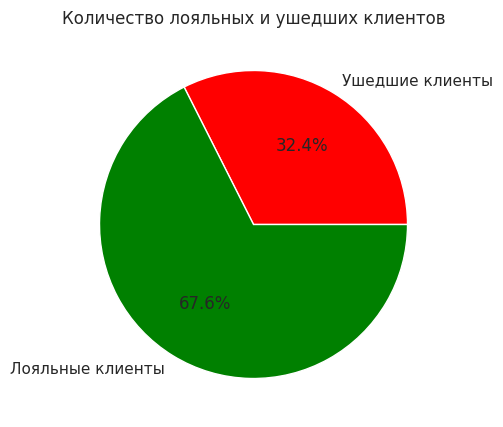

In [3]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ
out_bank = (df['Exited'] == 1).sum()
in_bank = (df['Exited'] == 0).sum()

plt.pie([out_bank, in_bank],
        labels=['Ушедшие клиенты', 'Лояльные клиенты'],
        autopct='%1.1f%%',
        colors=['red', 'green'])

plt.title('Количество лояльных и ушедших клиентов')
plt.show()
#КОНЕЦ ВАШЕГО РЕШЕНИЯ

**Лояльных клиентов 67,6% от общего числа, ушедших - 32,4%.**

## Задание 2 (12 баллов)
Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.

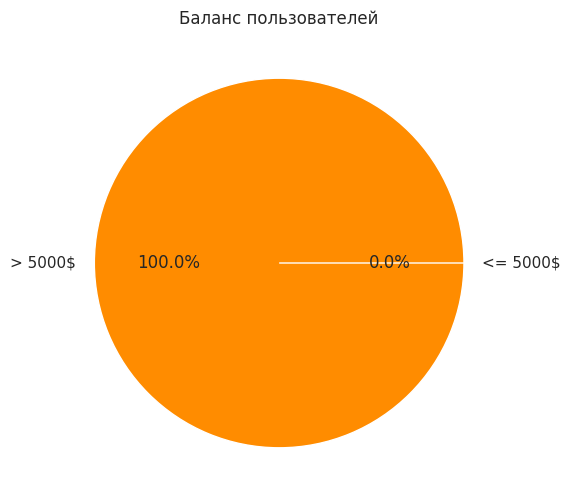

Баланс самого "бедного" пользователя банка: 27288.43


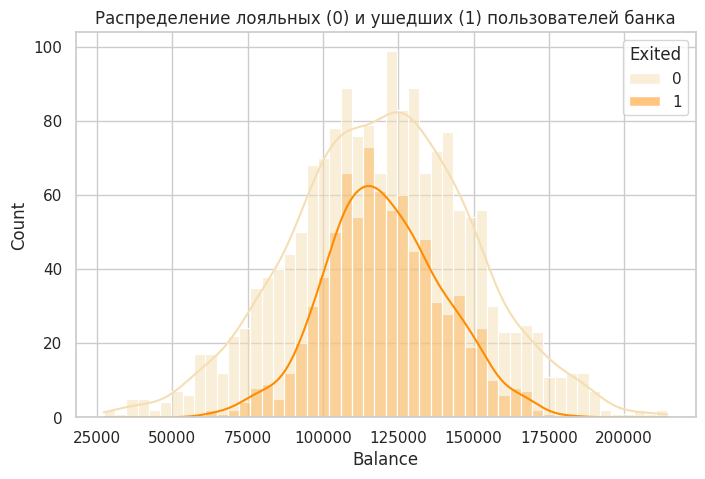

Среднее, медиана и первая мода распределения:
119730.1161339179
119703.1
130170.82


In [4]:
#НАЧАЛО ВАШЕГО РЕШЕНИя
big_client = (df['Balance'] > 5000).sum()
small_client = (df['Balance'] <= 5000).sum()

# смотрим, есть ли у нас клиенты с <= 5000$ на счетах
plt.figure(figsize=(8, 6))
plt.pie([big_client, small_client],
        labels=['> 5000$', '<= 5000$'],
        autopct='%1.1f%%',
        colors=['darkorange', 'wheat'])

plt.title('Баланс пользователей')
plt.show()

print(f'Баланс самого "бедного" пользователя банка: {(df['Balance']).min()}')

sns.histplot(data=df,
             x='Balance',
             hue='Exited',
             bins=50,
             kde=True,
             palette={0: 'wheat', 1: 'darkorange'})

plt.title('Распределение лояльных (0) и ушедших (1) пользователей банка')
plt.show()

print('Среднее, медиана и первая мода распределения:')
print(df['Balance'].mean())
print(df['Balance'].median())
print(df['Balance'].mode()[0])
# КОНЕЦ ВАШЕГО РЕШЕНИЯ

**Видно, что распределение баланса и лояльных, и ушедших пользователей банка похоже на нормальное.**

**Это подтверждается и тем, что среднее, мода и медиана практически равны.**

**Значит, мы получим стабильность в прогнозах, можно сделать вывод, что большинству клиентов подходят "стандартные" предложения, а также можно использовать параметрические статистические тесты, что предполагает легкость анализа.**

## Задание 3 (12 баллов)

Постройте тепловую карту по корреляционной матрице (Пирсона), сделайте выводы о линейной взаимосвязи между признаками.

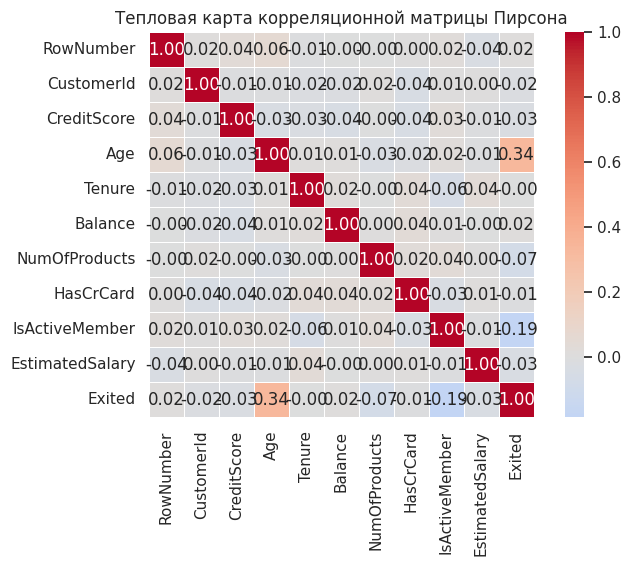

In [5]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ
corr_M = df.select_dtypes(include=[np.number]).corr(method='pearson')

heatmap = sns.heatmap(corr_M,
                      annot=True,
                      fmt='.2f',
                      cmap='coolwarm',
                      center=0,
                      square=True,
                      linewidths=0.5)

plt.title('Тепловая карта корреляционной матрицы Пирсона')
plt.show()
#КОНЕЦ ВАШЕГО РЕШЕНИЯ

**Видим умеренную корреляцию между возрастом и таргетом.**

**Этот признак стоит исследовать глубже.**

## Задание 4 (12 баллов)
Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?

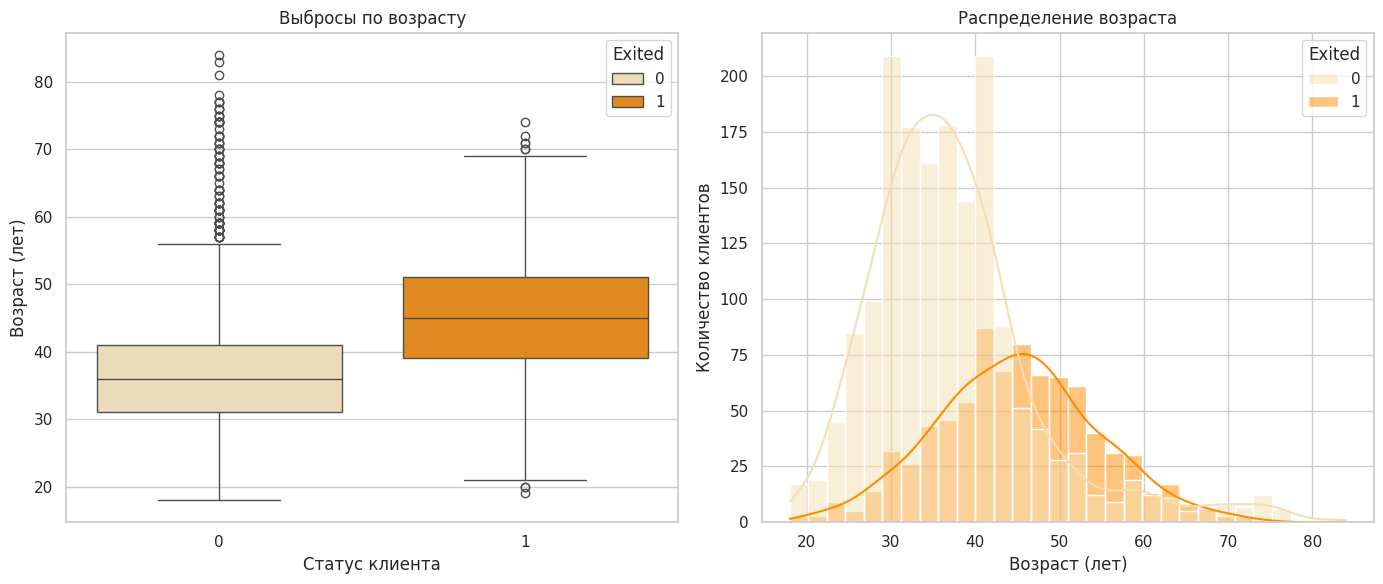

In [6]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# boxplot
sns.boxplot(data=df,
            x='Exited', y='Age', hue='Exited',
            palette=['wheat', 'darkorange'],
            ax=axes[0])

axes[0].set_title('Выбросы по возрасту')
axes[0].set_xlabel('Статус клиента')
axes[0].set_ylabel('Возраст (лет)')

# гистограмма распределения
sns.histplot(data=df,
             x='Age', hue='Exited',
             bins=30, kde=True,
             palette=['wheat','darkorange'],
             ax=axes[1])

axes[1].set_title('Распределение возраста')
axes[1].set_xlabel('Возраст (лет)')
axes[1].set_ylabel('Количество клиентов')

plt.tight_layout()
plt.show()
#КОНЕЦ ВАШЕГО РЕШЕНИЯ

**Видим, что в распределении лояльных клиентов значительно больше выбросов.**

**Также заметно, что средний возраст лояльных клиентов - около 35, тогда как средний возраст ушедших клиентов составляет 45 лет.**

**Выбросы - в лояльных клиентах очень много "старых" клиентов.**

**Похоже, что клиенты уходят просто по той причине, что постарели - и у них сменились ценности, они стали более консервативными - купили ферму, сняли наличку, и теперь просто отдыхают.**

## Задание 5 (13 баллов)
Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Есть ли взаимосвязь между признаками?

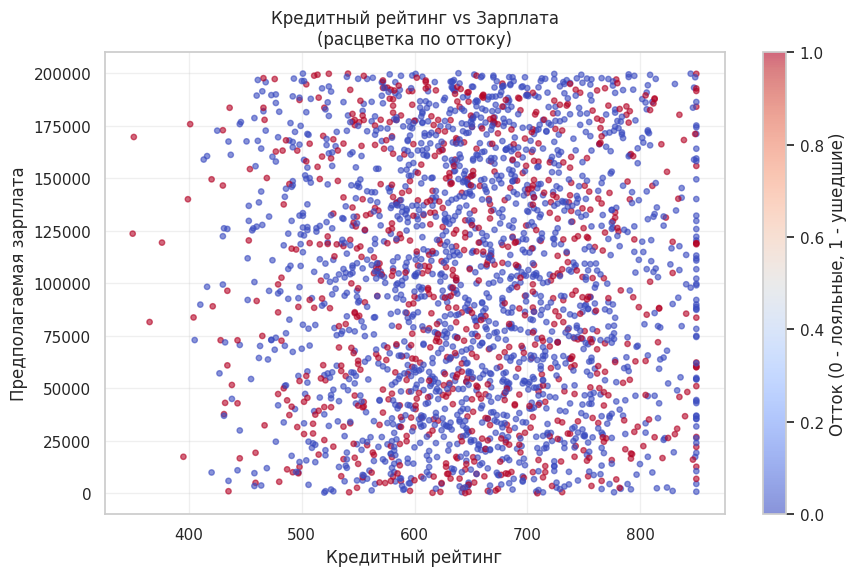

Корреляция: -0.0081
Значимой взаимосвязи нет.


In [7]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

scatter = axes.scatter(df['CreditScore'], df['EstimatedSalary'],
                        c=df['Exited'],
                        cmap='coolwarm',
                        alpha=0.6,
                        s=15)

axes.set_title('Кредитный рейтинг vs Зарплата\n(расцветка по оттоку)')
axes.set_xlabel('Кредитный рейтинг')
axes.set_ylabel('Предполагаемая зарплата')
axes.grid(True, alpha=0.3)

plt.colorbar(scatter, label='Отток (0 - лояльные, 1 - ушедшие)')
plt.show()

corr = df['CreditScore'].corr(df['EstimatedSalary'])
print(f'Корреляция: {corr:.4f}')

if abs(corr) > 0.3:
  print('Есть значимая взаимосвязь!')
else:
  print('Значимой взаимосвязи нет.')
#КОНЕЦ ВАШЕГО РЕШЕНИЯ

**Видно, что значимой корреляции между кредитным рейтингом и зарплатой нет.**

## Задание 6 (13 баллов)
Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.

*Подсказка: процент ушедших клиентов в каждой группе можно рассчитать как среднее по столбцу Exited (так как 1 — это ушедшие клиенты, а 0 — лояльные, среднее арифметическое по столбцу обозначает долю ушедших клиентов).*

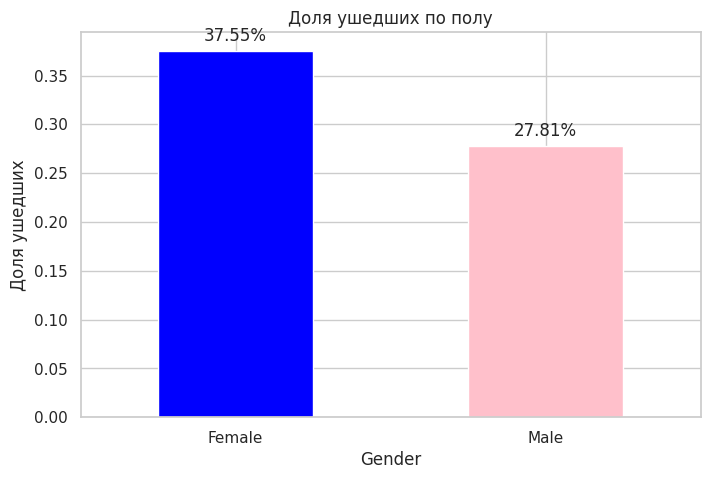

In [8]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ
churn_rate = df.groupby('Gender')['Exited'].mean()

churn_rate.plot(kind='bar', color=['blue', 'pink'])
plt.title('Доля ушедших по полу')
plt.ylabel('Доля ушедших')
plt.xticks(rotation=0)

for i, v in enumerate(churn_rate):
  plt.text(i, v + 0.01, f'{v:.2%}', ha='center')

plt.show()
#КОНЕЦ ВАШЕГО РЕШЕНИЯ

**Видно, что чаще уходят женщины - 37,55% против 27,81%.**

## Задание 7 (13 баллов)
Как отток клиентов зависит от числа приобретенных у банка услуг? Для ответа на этот вопрос используйте столбчатую диаграмму.

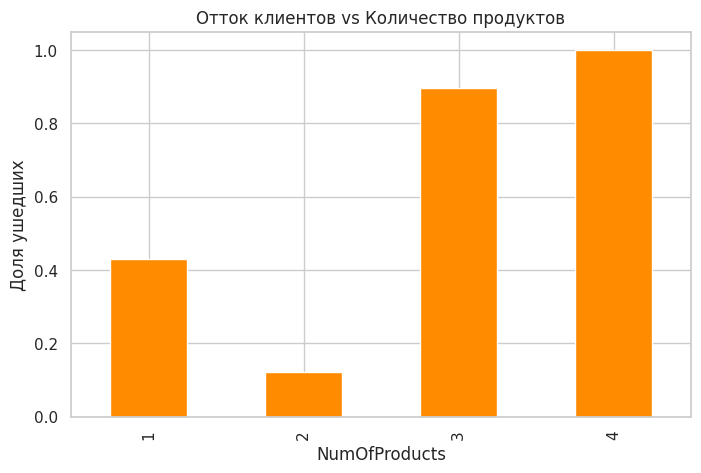

In [9]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ
df.groupby('NumOfProducts')['Exited'].mean().plot(kind='bar', color='darkorange')

plt.title('Отток клиентов vs Количество продуктов')
plt.ylabel('Доля ушедших')

plt.show()
#КОНЕЦ ВАШЕГО РЕШЕНИЯ

**Контринтуитивный вывод - чем большим кол-вом продуктов пользуются клиенты, чем выше риск его оттока.**

## Задание 8 (13 баллов)

Постройте сводную таблицу, где по строкам будет пол (`Gender`), по столбцам — число приобретенных услуг (`NumOfProducts`), а в ячейках — суммарное число ушедших клиентов в этой группе (`Exited`). Затем визуализируйте эту таблицу с помощью тепловой карты и сделайте выводы.

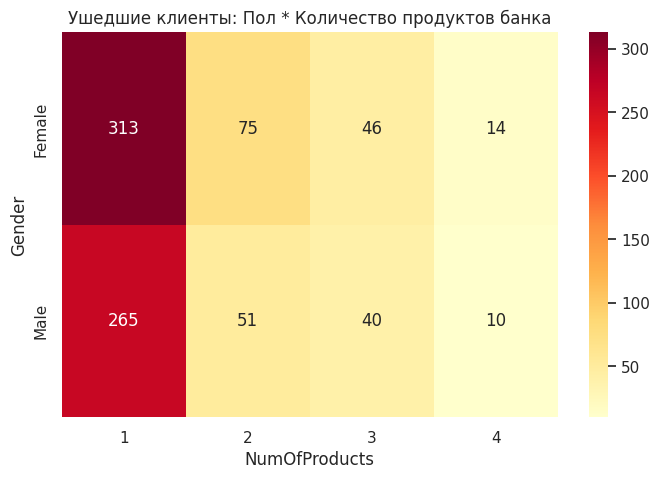

In [10]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ
pivot = df.pivot_table(index='Gender', columns='NumOfProducts', values='Exited', aggfunc='sum')

sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Ушедшие клиенты: Пол * Количество продуктов банка')

plt.show()
#КОНЕЦ ВАШЕГО РЕШЕНИЯ

**Мы получили действительно любопытные наблюдения!**

**Самая "проблемная" категория клиентов банка - женщины.**

**Они имеют большую вероятность оттока в сравнению с мужчинами.**

**Нужно стараться увеличивать количество продуктов хотя бы до двух - эта мера поможет снизить отток по крайней мере в 5 раз - причем для обоих групп!!!**

**4 продукта не гарантируют лояльность - это значит, что стоит работать над качеством продукта, и, возможно, над более узкопрофильными предложениями для каждого конкретного клиента.**